# Variational Autoencoder (VAE) 

A VAE learns a latent representation $z$ of data $x$ by jointly training:
- An **encoder** $q_\phi(z|x)$ that maps inputs to a distribution over latent space
- A **decoder** $p_\theta(x|z)$ that reconstructs inputs from latent samples

The model is trained by maximizing the **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}(q_\phi(z|x) \| p(z))$$

## 1. Imports & Hyperparameters

We train on the MNIST dataset ($28 \times 28$ grayscale images) with a latent dimension $d_z$.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
LATENT_DIM = 2       # low dim for easy visualization
INPUT_DIM = 28 * 28  # MNIST

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load MNIST Dataset

Each image $x \in [0, 1]^{784}$ is flattened from $28 \times 28$ pixels and normalized to $[0, 1]$ via a `ToTensor()` transform so we can model it with a Bernoulli likelihood.

In [2]:
transform = transforms.ToTensor()  # scales pixels to [0, 1]

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} samples | Test: {len(test_dataset)} samples")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]

Train: 60000 samples | Test: 10000 samples


## 3. VAE Architecture

### Encoder
The encoder maps an input $x$ to the parameters of a Gaussian posterior:

$$q_\phi(z|x) = \mathcal{N}(z; \mu_\phi(x),\, \text{diag}(\sigma_\phi^2(x)))$$

where $\mu_\phi(x)$ and $\log \sigma_\phi^2(x)$ are outputs of a neural network.

### Reparameterization Trick
To allow gradients to flow through the sampling step, we reparameterize:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

This separates the stochastic node from the deterministic computation.

### Decoder
The decoder reconstructs $x$ from $z$ - each pixel value is from 0 to 1 and its near-binary (mostly black and white):

$$p_\theta(x|z) = \prod_{i=1}^{784} \text{Bernoulli}(x_i; \hat{x}_i(z))$$

where $\hat{x}(z) = \sigma(W_d z + b_d)$ and $\sigma$ is the sigmoid function.

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 512, latent_dim: int = 2):
        super().__init__()
        # --- Encoder ---
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)  # μ(x)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)  # log σ²(x)

        # --- Decoder ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),  # output ∈ [0, 1] for Bernoulli likelihood
        )

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        """z = μ + σ ⊙ ε,  ε ~ N(0, I)"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var

model = VAE(INPUT_DIM, latent_dim=LATENT_DIM).to(device)
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=512, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=512, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## 4. Loss Function

The VAE loss has two terms:

### Reconstruction Loss (Binary Cross-Entropy)
Since we model pixels as Bernoulli, the negative log-likelihood is:

$$\mathcal{L}_{\text{recon}} = -\sum_{i=1}^{784} \Big[ x_i \log \hat{x}_i + (1 - x_i) \log (1 - \hat{x}_i) \Big]$$

### KL Divergence
The KL divergence between the learned posterior $q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2 I)$ and the prior $p(z) = \mathcal{N}(0, I)$ has a closed-form solution:

$$D_{KL}\big(q_\phi(z|x) \| p(z)\big) = -\frac{1}{2} \sum_{j=1}^{d_z} \Big(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2 \Big)$$

### Total Loss
$$\mathcal{L} = \mathcal{L}_{\text{recon}} + D_{KL}$$

<details>
<summary><em>Optional: deriving the closed-form KL from Gaussian distributions</em></summary>

We want to compute $D_{KL}(q \| p)$ where:

$$q(z) = \mathcal{N}(\mu, \sigma^2), \qquad p(z) = \mathcal{N}(0, 1)$$

**Step 1 — Definition**

$$D_{KL}(q \| p) = \int q(z) \log \frac{q(z)}{p(z)}\, dz = \mathbb{E}_q\!\left[\log q(z) - \log p(z)\right]$$

**Step 2 — Write out the log-densities**

$$\log q(z) = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{(z - \mu)^2}{2\sigma^2}$$

$$\log p(z) = -\frac{1}{2}\log(2\pi) - \frac{z^2}{2}$$

**Step 3 — Take the difference**

$$\log q(z) - \log p(z) = -\frac{1}{2}\log\sigma^2 - \frac{(z-\mu)^2}{2\sigma^2} + \frac{z^2}{2}$$

**Step 4 — Take the expectation under $q$**

Use two standard Gaussian moment results:

$$\mathbb{E}_q\!\left[(z - \mu)^2\right] = \sigma^2, \qquad \mathbb{E}_q\!\left[z^2\right] = \sigma^2 + \mu^2$$

Substituting term by term:

$$D_{KL} = -\frac{1}{2}\log\sigma^2 \;-\; \frac{1}{2}\underbrace{\frac{\mathbb{E}_q[(z-\mu)^2]}{\sigma^2}}_{=\,1} \;+\; \frac{1}{2}\underbrace{\mathbb{E}_q[z^2]}_{=\,\sigma^2+\mu^2}$$

$$= -\frac{1}{2}\log\sigma^2 - \frac{1}{2} + \frac{1}{2}(\sigma^2 + \mu^2)$$

**Step 5 — Rearrange**

$$\boxed{D_{KL} = -\frac{1}{2}\Big(1 + \log\sigma^2 - \mu^2 - \sigma^2\Big)}$$

Since the diagonal Gaussian factorizes over $d_z$ independent dimensions, the total KL is just the sum:

$$D_{KL}\big(q_\phi(z|x) \| p(z)\big) = -\frac{1}{2}\sum_{j=1}^{d_z}\Big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\Big)$$

</details>

In [4]:
def vae_loss(x_recon: torch.Tensor, x: torch.Tensor,
            mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
    # Reconstruction: binary cross-entropy summed over pixels, averaged over batch
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum")

    # KL divergence: -0.5 * Σ(1 + log σ² - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return (recon_loss + kl_loss) / x.size(0)

## 5. Training

We optimize the ELBO using Adam. At each step we:

1. Flatten $x$ to $\mathbb{R}^{784}$
2. Forward pass: encode → reparameterize → decode
3. Compute $\mathcal{L} = \mathcal{L}_{\text{recon}} + D_{KL}$
4. Backpropagate and update $\theta, \phi$

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch_x, _ in train_loader:
        batch_x = batch_x.view(-1, INPUT_DIM).to(device)

        x_recon, mu, log_var = model(batch_x)
        loss = vae_loss(x_recon, batch_x, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_x.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>2}/{EPOCHS}]  Loss: {avg_loss:.2f}")

Epoch [ 1/20]  Loss: 179.41
Epoch [ 5/20]  Loss: 146.83
Epoch [10/20]  Loss: 142.12
Epoch [15/20]  Loss: 139.83
Epoch [20/20]  Loss: 138.39


### Training Loss Curve

The loss should decrease as the model learns to reconstruct digits while keeping the latent distribution close to $\mathcal{N}(0, I)$.

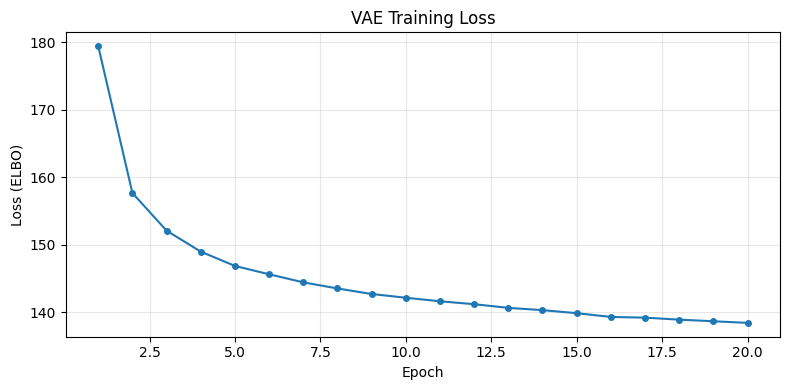

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss (ELBO)")
plt.title("VAE Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Reconstruction Quality

We pass test images through the full pipeline and compare originals vs. reconstructions:

$$x \xrightarrow{\text{encode}} (\mu, \log\sigma^2) \xrightarrow{\text{reparam.}} z \xrightarrow{\text{decode}} \hat{x}$$

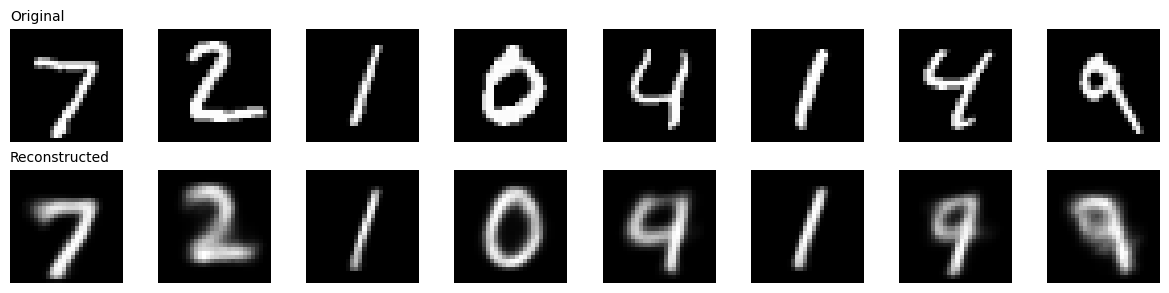

In [7]:
model.eval()
with torch.no_grad():
    test_x, _ = next(iter(test_loader))
    test_x_flat = test_x.view(-1, INPUT_DIM).to(device)
    recon, _, _ = model(test_x_flat)
    recon = recon.cpu().view(-1, 1, 28, 28)

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
for i in range(n):
    axes[0, i].imshow(test_x[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Original", fontsize=10, loc="left")
axes[1, 0].set_title("Reconstructed", fontsize=10, loc="left")
plt.tight_layout()
plt.show()

## 7. Generation
**Sample from the prior** and decode:
$$z \sim \mathcal{N}(0, I), \quad \hat{x} = \text{Decoder}_\theta(z)$$

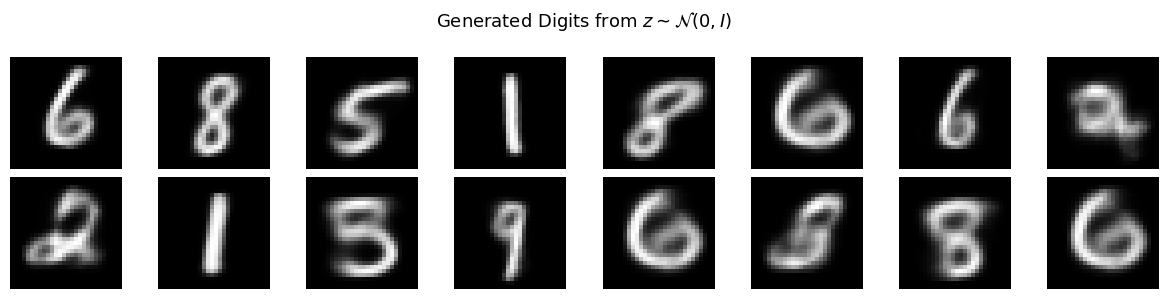

In [11]:
num_samples = 16

with torch.no_grad():
    # Sample z from standard Gaussian N(0, I)
    z_samples = torch.randn(num_samples, LATENT_DIM).to(device)
    generated = model.decode(z_samples).cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, num_samples // 2, figsize=(num_samples // 2 * 1.5, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap="gray")
    ax.axis("off")
fig.suptitle("Generated Digits from $z \\sim \\mathcal{N}(0, I)$", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Latent Space Manifold

Since $d_z = 2$, we can visualize the learned manifold by sweeping a grid over the latent space. We use the inverse CDF of the standard normal (percent-point function) to map uniform grid points $u \in (0, 1)$ to $z$ values:

$$z_j = \Phi^{-1}(u_j), \quad u_j \in \{0.05, 0.10, \ldots, 0.95\}$$

Each grid point is decoded into a $28 \times 28$ image, giving a smooth panorama of generated digits.

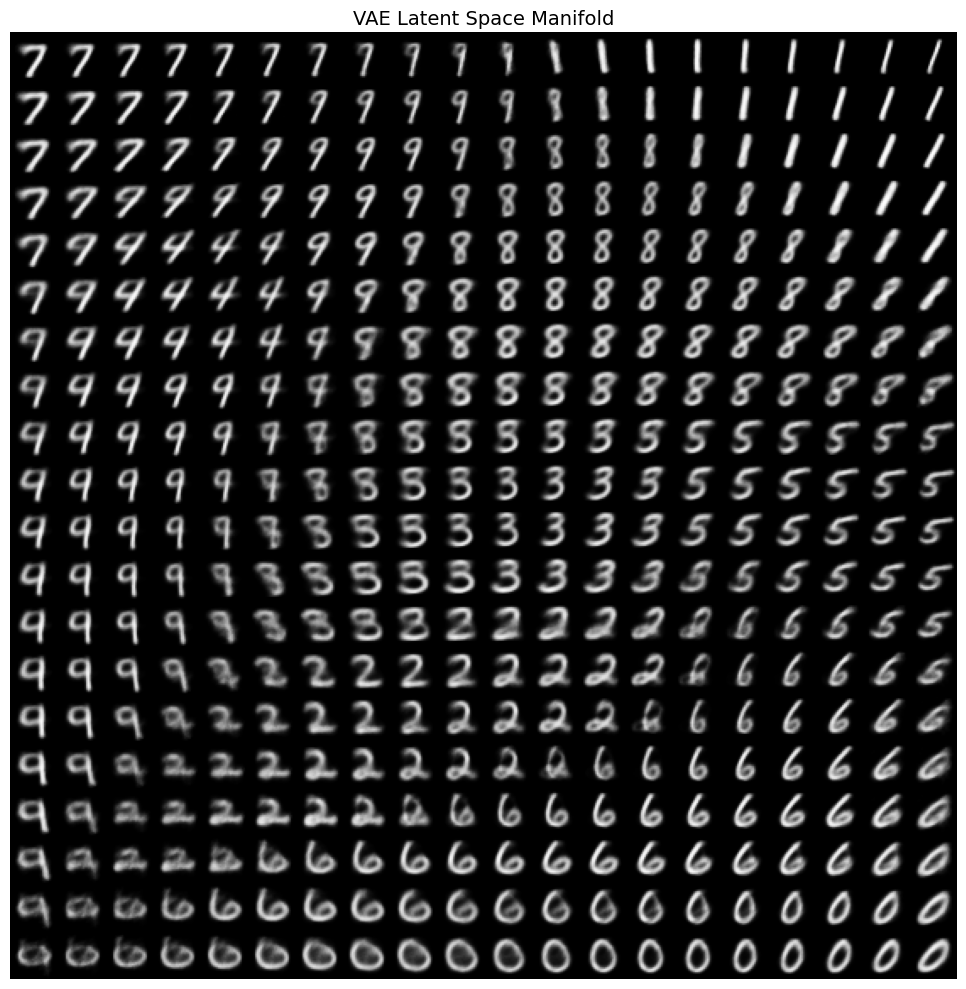

In [13]:

from scipy.stats import norm

n = 20  # grid size
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Linearly spaced quantiles
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            digit = model.decode(z).cpu().numpy().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.title("VAE Latent Space Manifold", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()